In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

path = r'C:\Users\howel\OneDrive\NYC_CitiBike_Project'

In [5]:
# Load the data so 'df' is defined
df = pd.read_csv(os.path.join(path, '02 Data', 'Prepared Data', 'citibike_cleaned.csv'), low_memory=False)

In [6]:
# 1. Ensure 'started_at' is a datetime object
df['started_at'] = pd.to_datetime(df['started_at'])

# 2. Create a 'Date' column and count rides per day
df_temp = df.groupby(df['started_at'].dt.date).size().reset_index(name='trip_count')

# 3. Set the Date as the index (crucial for time series)
df_temp['started_at'] = pd.to_datetime(df_temp['started_at'])
df_ts = df_temp.set_index('started_at')

In [7]:
df_ts.head()

,trip_count
started_at,
2025-01-31,265
2025-02-01,72066
2025-02-02,51171
2025-02-03,85770
2025-02-04,94458


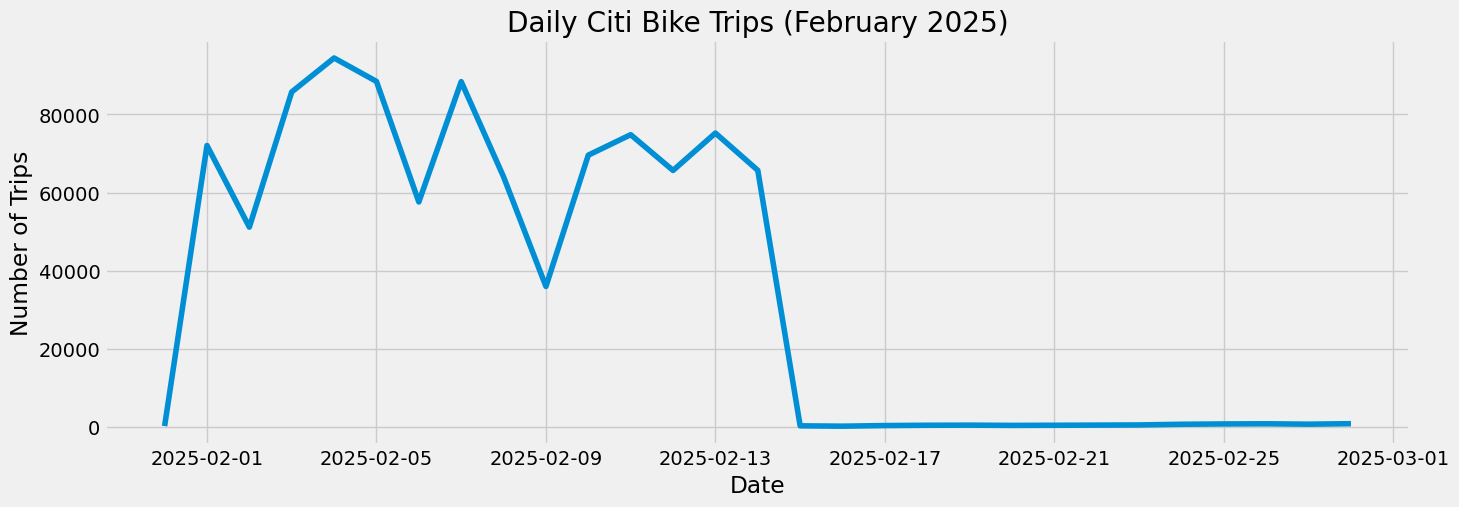

In [8]:
# Create a line chart of the daily trip counts
plt.figure(figsize=(15,5))
plt.plot(df_ts)
plt.title('Daily Citi Bike Trips (February 2025)')
plt.xlabel('Date')
plt.ylabel('Number of Trips')
plt.show()

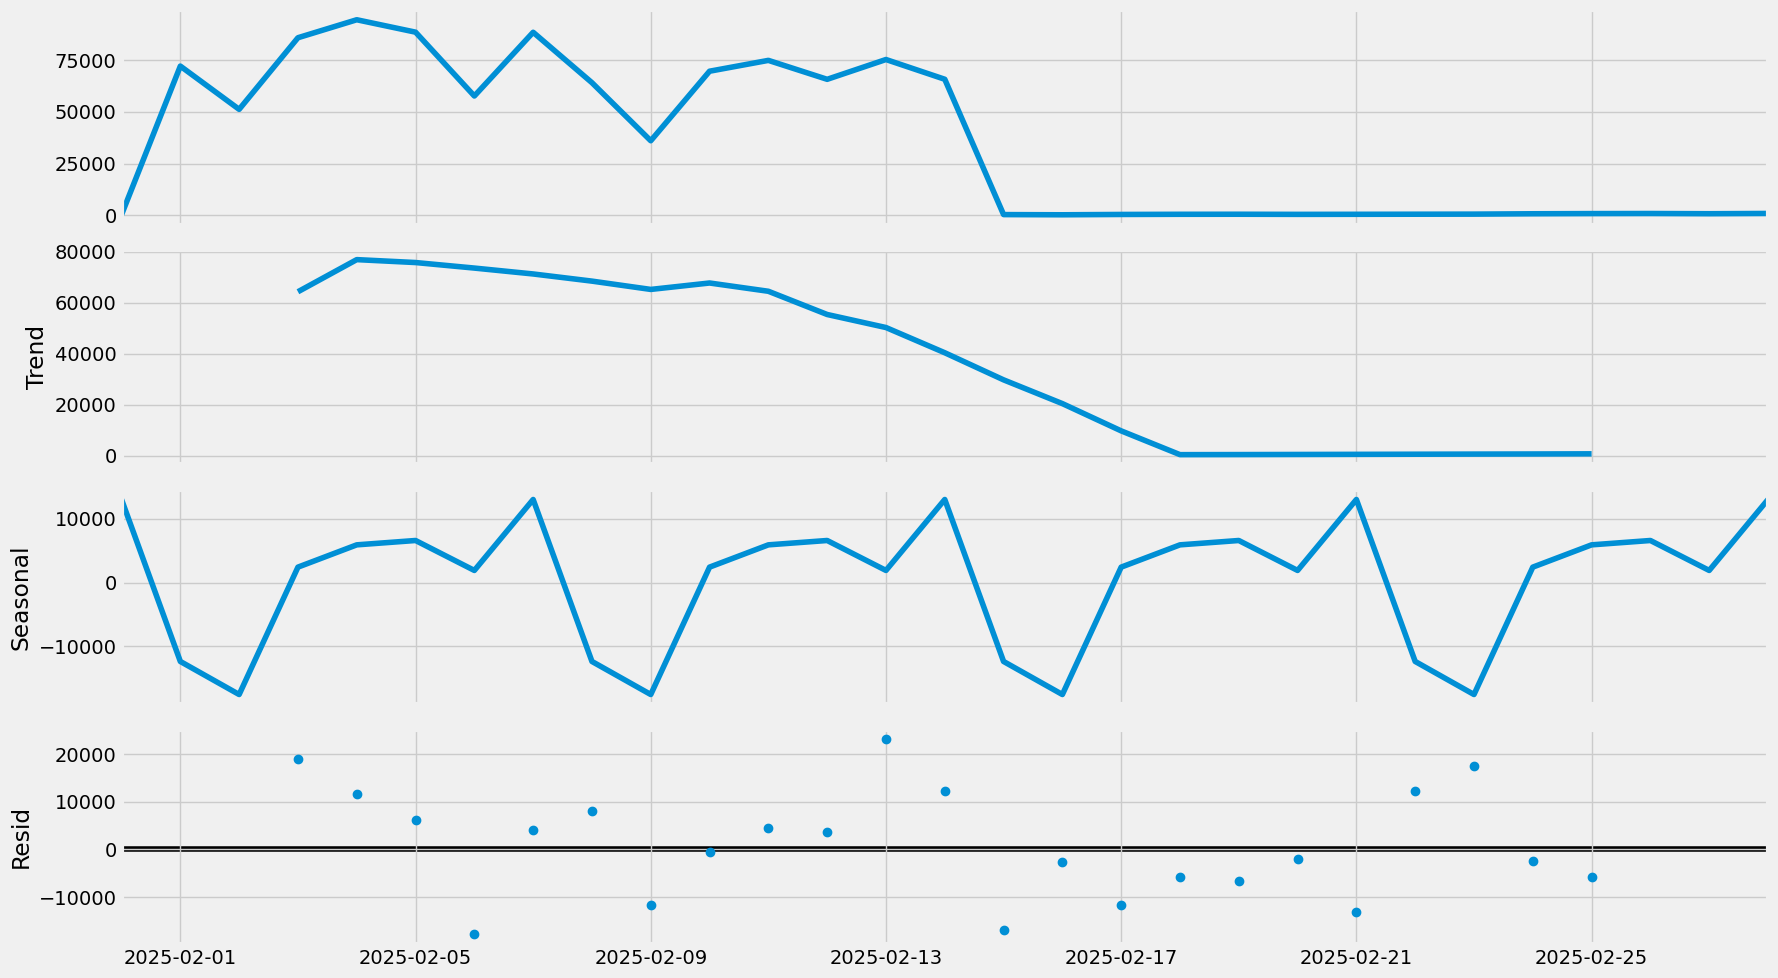

In [9]:
# Decompose the time series using an additive model
decomposition = sm.tsa.seasonal_decompose(df_ts, model='additive')

# Plot the separate components
from pylab import rcParams
rcParams['figure.figsize'] = 18, 10
decomposition.plot()
plt.show()

Original Data (Top Chart): Shows the raw count of daily trips. We see a sharp drop-off in activity starting around mid-February.

Trend: This component smooths out the noise to show the overall direction. There is a clear downward trend in ridership as the month progresses, eventually flattening out near zero.

Seasonal: You have identified a strong weekly seasonality. The regular "spikes" and "dips" represent the difference between weekday commuting peaks and weekend troughs.

Resid (Residual): This is the "noise" or unexplained variance. The dots far from the zero line represent days where ridership was unexpectedly high or low, perhaps due to severe NYC winter weather.

In [10]:
from statsmodels.tsa.stattools import adfuller

def dickey_fuller_test(timeseries):
    print('Dickey-Fuller Test Results:')
    df_test = adfuller(timeseries, autolag='AIC')
    df_output = pd.Series(df_test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df_test[4].items():
       df_output['Critical Value (%s)'%key] = value
    print(df_output)

# Run the test on your trip_count column
dickey_fuller_test(df_ts['trip_count'])

Dickey-Fuller Test Results:
Test Statistic                 -1.753384
p-value                         0.403838
#Lags Used                      0.000000
Number of Observations Used    28.000000
Critical Value (1%)            -3.688926
Critical Value (5%)            -2.971989
Critical Value (10%)           -2.625296
dtype: float64


Null Hypothesis (H_0): The data contains a unit root and is non-stationary.

Test Statistic (-1.753): This value is larger than the Critical Value (5%) of -2.972.

P-value (0.403): This is significantly higher than the 0.05 threshold for statistical significance.

Conclusion: Because the test statistic is larger than the critical value, I cannot reject the null hypothesis. My data is non-stationary.

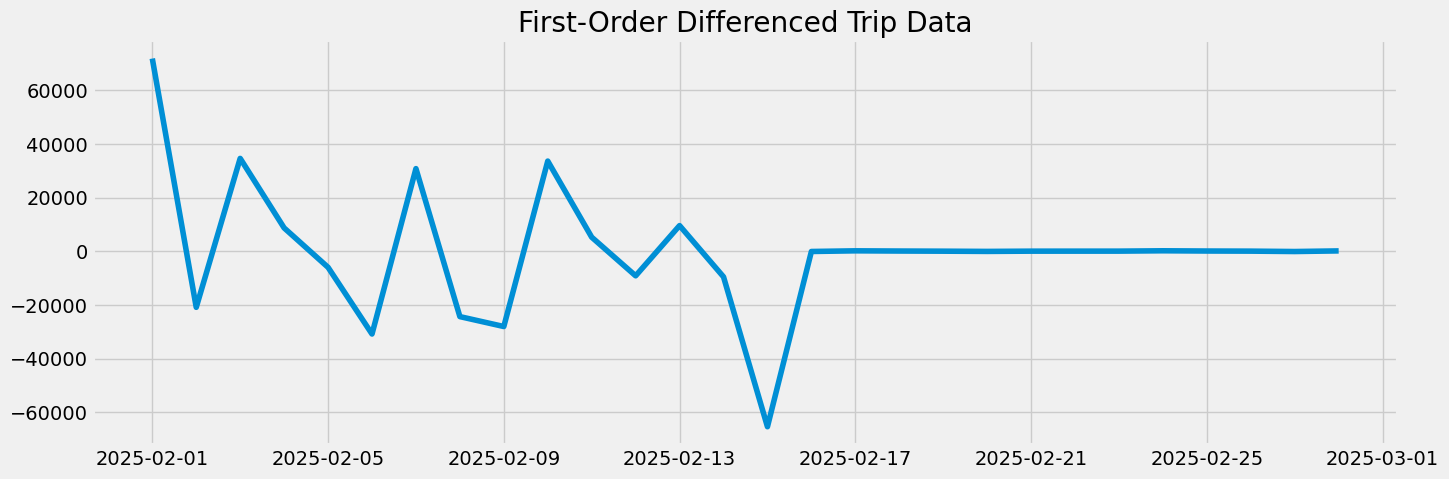

Dickey-Fuller Test Results:
Test Statistic                -7.594924e+00
p-value                        2.474891e-11
#Lags Used                     0.000000e+00
Number of Observations Used    2.700000e+01
Critical Value (1%)           -3.699608e+00
Critical Value (5%)           -2.976430e+00
Critical Value (10%)          -2.627601e+00
dtype: float64


In [11]:
# Create a differenced dataset
data_diff = df_ts - df_ts.shift(1)

# Remove the NaN value created by the shift
data_diff.dropna(inplace=True)

# Visualize the differenced data
plt.figure(figsize=(15,5))
plt.plot(data_diff)
plt.title('First-Order Differenced Trip Data')
plt.show()

# Re-run the Dickey-Fuller test on the new differenced data
dickey_fuller_test(data_diff['trip_count'])

Test Statistic (-7.59): Your new test statistic is now significantly smaller than the Critical Value (5%) of -2.97.

P-value ($2.47 \times 10^{-11}$): This value is effectively zero, which is well below the 0.05 threshold for statistical significance.

Conclusion: Because the test statistic is smaller than the critical value, I can now reject the null hypothesis. This confirms that the series is now stationary and ready for forecasting models.

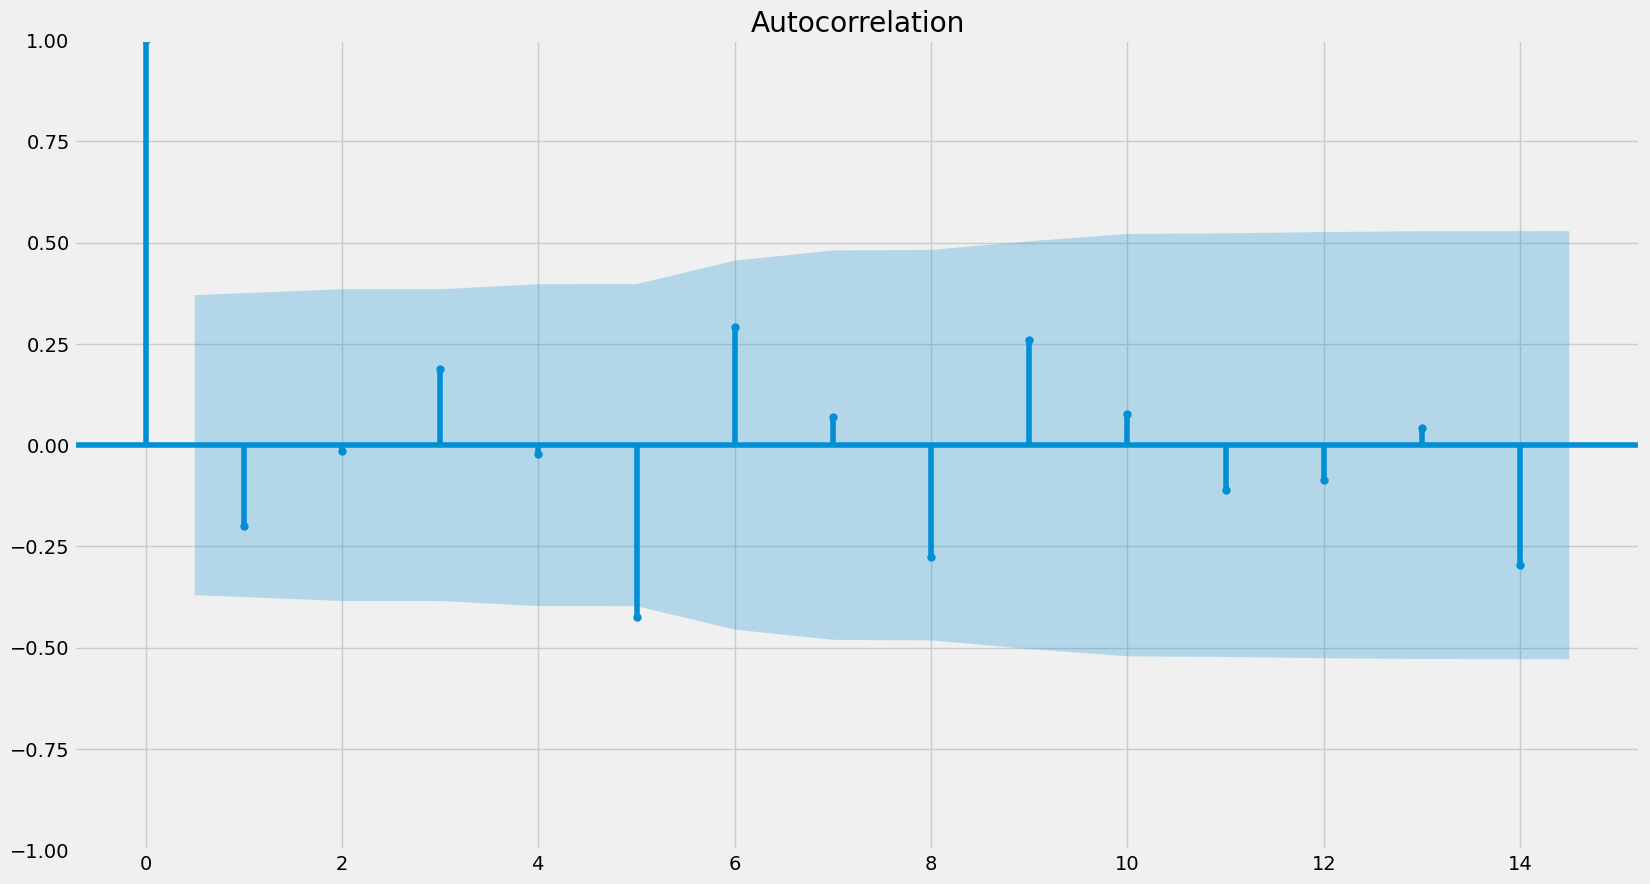

In [12]:
from statsmodels.graphics.tsaplots import plot_acf

# Check for autocorrelations in the stationarized (differenced) data
plot_acf(data_diff)
plt.show()

1. Autocorrelation Results

   The ACF plot shows that after one round of differencing, the vertical lines (lags) have mostly retreated within the blue confidence interval. This      indicates that the serial correlation has been removed and the data is now truly stationary. Since we have fewer than ten significant lags              remaining, no further differencing is required.

2. Stationarity Reached

   My Dickey-Fuller test result of -7.59 is significantly smaller than the Critical Value (5%) of -2.97. With a p-value essentially at zero, we have       successfully disproven the null hypothesis (H_0) and proven my data is ready for forecasting.